In [ ]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
import torchvision.transforms.functional as TF


from src.nn.models import UNet, train_loop, test_loop
from src.nn.optimizers import create_optimizer
from src.plot.plot import plot_resultados
from src.dataset.sintetic import SyntheticEllipses

In [2]:
# Definindo a seed e o device (GPU se disponível, caso contrário CPU)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Definindo o dataset sintético, dataloaders, modelo, função de perda e otimizador
dataset = SyntheticEllipses(n=120, size=128)
train_dataset, val_dataset = random_split(
    dataset,
    [100, 20],
    generator=torch.Generator().manual_seed(SEED)
)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
model = UNet(num_classes=2).to(device)

# Funções de perda ponderadas para lidar com o desbalanceamento das classes
# Classe 0 = background
# Classe 1 = ellipse
# Damos menos peso ao background e mais peso às elipses.
weights = torch.tensor([0.25, 1.75],dtype=torch.float32).to(device)
loss_fn = nn.CrossEntropyLoss(weight=weights)

# Otimizador
optimizer = create_optimizer("Adam", model, lr=1e-3)

print("Device:", device)
print("Model:", model)
print("Optimizer:", optimizer)

Device: cpu
Model: UNet(
  (enc1): ConvBlock(
    (block): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc2): ConvBlock(
    (block): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc3): ConvBlock(
    (bl

Epoch 1/5 | Train Loss: 0.2835 | Val Loss: 0.4985 | Pixel Accuracy: 0.9733


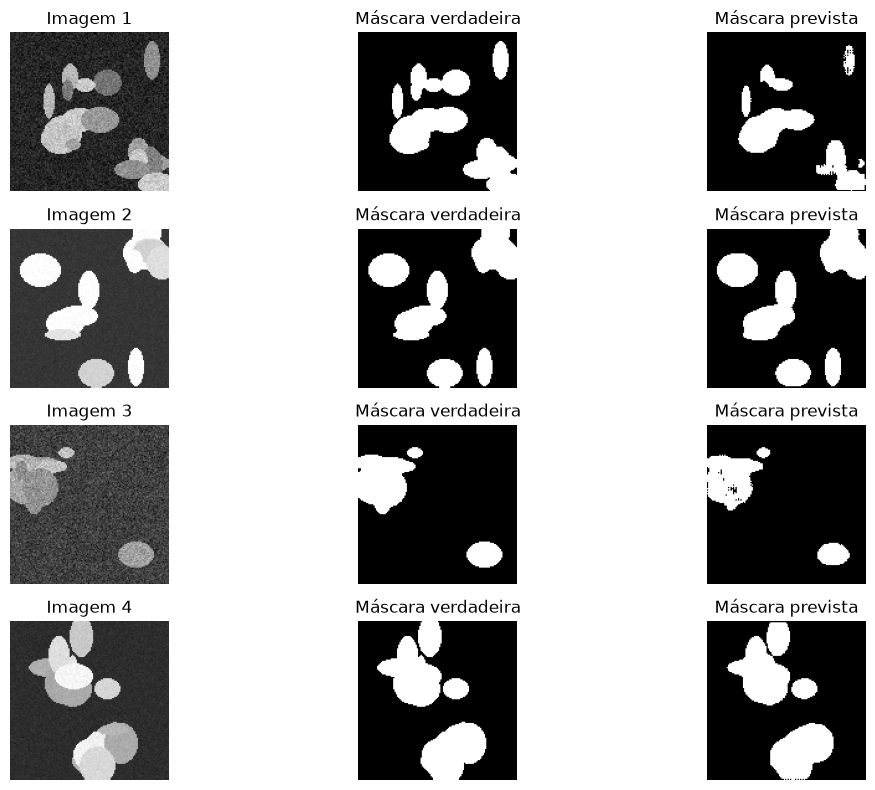

Epoch 2/5 | Train Loss: 0.1674 | Val Loss: 0.2378 | Pixel Accuracy: 0.9794


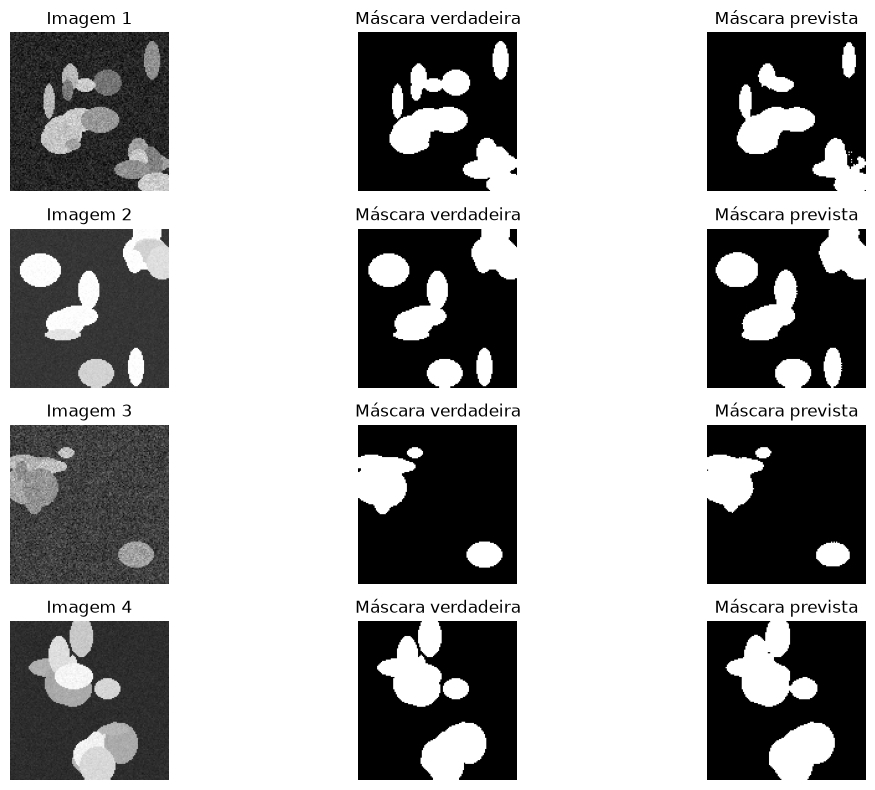

Epoch 3/5 | Train Loss: 0.1349 | Val Loss: 0.1791 | Pixel Accuracy: 0.9376


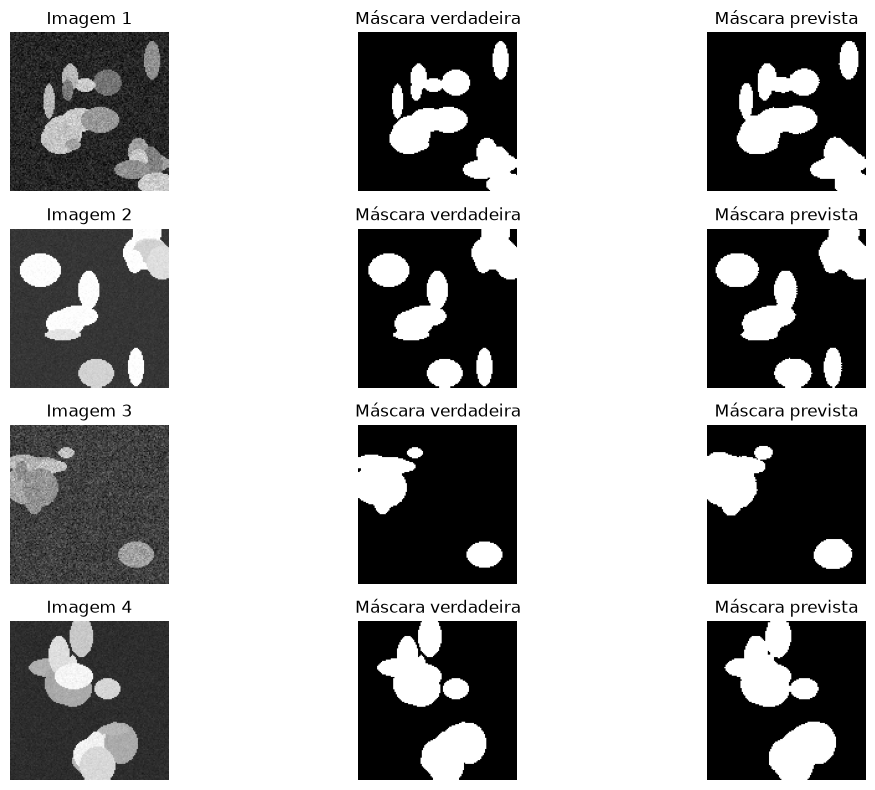

Epoch 4/5 | Train Loss: 0.1178 | Val Loss: 0.1365 | Pixel Accuracy: 0.9768


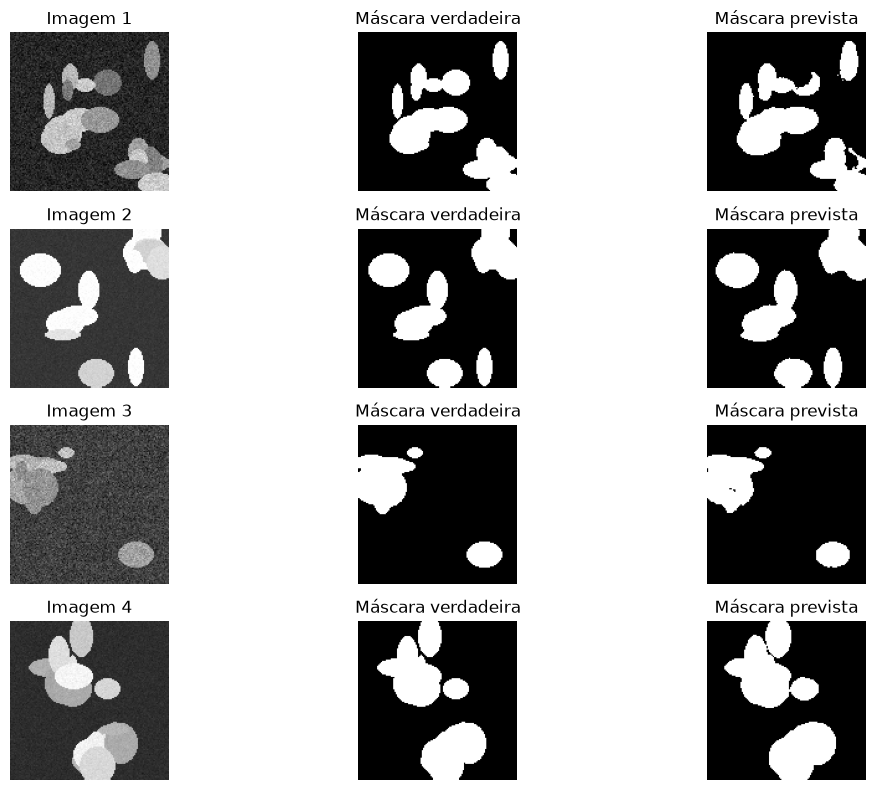

Epoch 5/5 | Train Loss: 0.1139 | Val Loss: 0.1162 | Pixel Accuracy: 0.9824


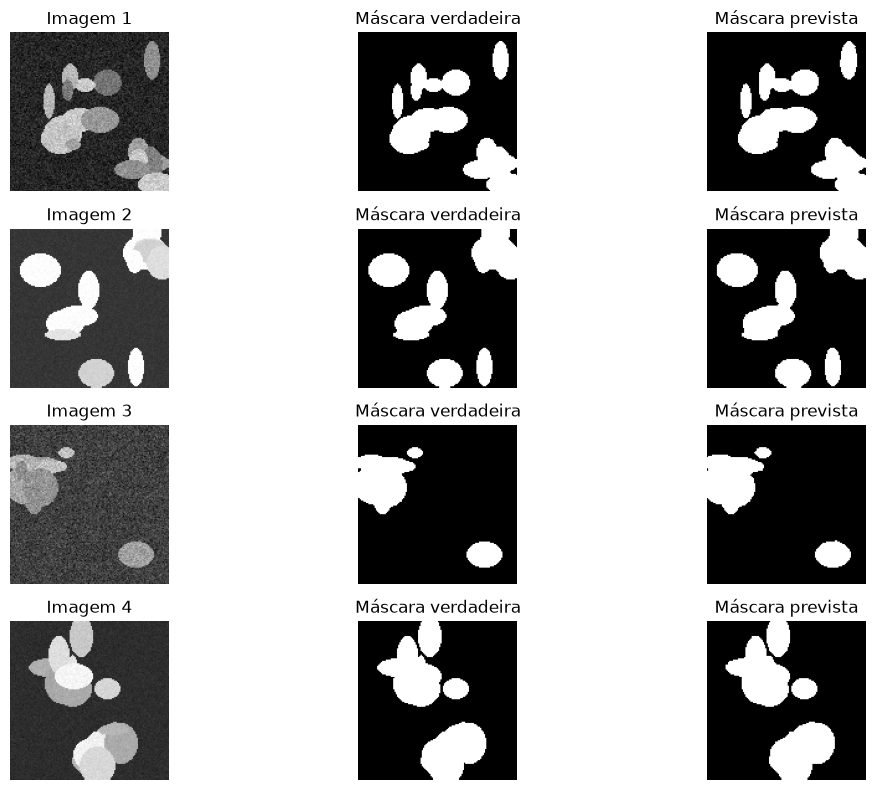

In [3]:
# Treinamento e validação do modelo
NUM_EPOCHS = 5
for epoch in range(NUM_EPOCHS):
    train_loss = train_loop(train_loader, device, model, loss_fn, optimizer)
    val_loss, pixel_acc = test_loop(val_loader, device, model, loss_fn)
    print(
        f"Epoch {epoch + 1}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Pixel Accuracy: {pixel_acc:.4f}"
    )
    plot_resultados(model, val_loader, device, num_images=4)